In [269]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

# Step 1: Collect API Data
url = "https://api.github.com/search/repositories?q=machine+learning&sort=stars&order=desc&per_page=100"
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    items = data["items"]

    # Step 2: Create the Dataset
    df = pd.DataFrame(items)
    print("Data fetched successfully!")
    print("Shape of original dataset:", df.shape)
    display(df.head(3))
else:
    print("Failed to fetch data, status code:", response.status_code)

Failed to fetch data, status code: 403


In [270]:
# Exploration
print(df.head())

                       name     owner_login          language   stars  forks  \
0                tensorflow      tensorflow               C++  197559  76115   
1              transformers     huggingface            Python  164402  34342   
2          ML-For-Beginners       microsoft  Jupyter Notebook   89752  22063   
3                    funNLP  fighting41love            Python   82640  15278   
4  awesome-machine-learning    josephmisiti            Python   74145  15621   

   watchers  open_issues created_date updated_date        license_name  
0    197559         2929   2015-11-07   2026-08-24  Apache License 2.0  
1    164402         2396   2018-10-29   2026-08-24  Apache License 2.0  
2     89752           13   2021-03-03   2026-08-24         MIT License  
3     82640           52   2018-08-21   2026-08-24          No License  
4     74145           26   2014-07-15   2026-08-24               Other  


In [271]:
print(df.tail())

                                  name    owner_login          language  \
95     Machine-learning-learning-notes       Vay-keen           Unknown   
96                   awesome-youtubers  JoseDeFreitas          Markdown   
97  Learn_Machine_Learning_in_3_Months     llSourcell           Unknown   
98                               h2o-3          h2oai  Jupyter Notebook   
99           industry-machine-learning         firmai  Jupyter Notebook   

    stars  forks  watchers  open_issues created_date updated_date  \
95   7763   1879      7763           28   2018-03-24   2026-08-24   
96   7749    498      7749            2   2020-08-25   2026-08-24   
97   7603   2311      7603           19   2018-03-02   2026-08-21   
98   7495   2025      7495         2884   2014-03-03   2026-08-21   
99   7484   1249      7484            3   2019-05-03   2026-08-23   

                            license_name  
95                            No License  
96  Creative Commons Zero v1.0 Universal  
97   

In [272]:
print(df.shape)

(100, 10)


In [273]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          100 non-null    object
 1   owner_login   100 non-null    object
 2   language      100 non-null    object
 3   stars         100 non-null    int64 
 4   forks         100 non-null    int64 
 5   watchers      100 non-null    int64 
 6   open_issues   100 non-null    int64 
 7   created_date  100 non-null    object
 8   updated_date  100 non-null    object
 9   license_name  100 non-null    object
dtypes: int64(4), object(6)
memory usage: 7.9+ KB
None


In [274]:
print(df.describe())

               stars        forks       watchers  open_issues
count     100.000000    100.00000     100.000000   100.000000
mean    20830.930000   4816.26000   20830.930000   265.340000
std     27332.101884   8772.55047   27332.101884   589.677882
min      7484.000000    498.00000    7484.000000     0.000000
25%      9417.250000   1783.00000    9417.250000    12.000000
50%     13480.500000   2882.50000   13480.500000    32.500000
75%     20269.000000   4437.00000   20269.000000   183.500000
max    197559.000000  76115.00000  197559.000000  2929.000000


In [275]:
# Step 3: Select Required Columns
required_cols = [
    "name",
    "owner_login",
    "language",
    "stars",
    "forks",
    "watchers",
    "open_issues",
    "created_date",
    "updated_date",
    "license_name",
]

df = df[required_cols]

df.head()

,name,owner_login,language,stars,forks,watchers,open_issues,created_date,updated_date,license_name
0,tensorflow,tensorflow,C++,197559,76115,197559,2929,2015-11-07,2026-08-24,Apache License 2.0
1,transformers,huggingface,Python,164402,34342,164402,2396,2018-10-29,2026-08-24,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89752,22063,89752,13,2021-03-03,2026-08-24,MIT License
3,funNLP,fighting41love,Python,82640,15278,82640,52,2018-08-21,2026-08-24,No License
4,awesome-machine-learning,josephmisiti,Python,74145,15621,74145,26,2014-07-15,2026-08-24,Other


In [276]:
# Step 4: Extract nested JSON values safely (prevents KeyError if already run)
if 'owner' in df.columns:
    df['owner_login'] = df['owner'].apply(lambda x: x.get('login') if isinstance(x, dict) else None)

if 'license' in df.columns:
    df['license_name'] = df['license'].apply(lambda x: x.get('name') if isinstance(x, dict) and x.get('name') else 'No License')

# Drop the original nested columns safely if they exist
columns_to_drop = [col for col in ['owner', 'license'] if col in df.columns]
if columns_to_drop:
    df = df.drop(columns=columns_to_drop)

df.head()

,name,owner_login,language,stars,forks,watchers,open_issues,created_date,updated_date,license_name
0,tensorflow,tensorflow,C++,197559,76115,197559,2929,2015-11-07,2026-08-24,Apache License 2.0
1,transformers,huggingface,Python,164402,34342,164402,2396,2018-10-29,2026-08-24,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89752,22063,89752,13,2021-03-03,2026-08-24,MIT License
3,funNLP,fighting41love,Python,82640,15278,82640,52,2018-08-21,2026-08-24,No License
4,awesome-machine-learning,josephmisiti,Python,74145,15621,74145,26,2014-07-15,2026-08-24,Other


In [277]:
# Step 5: Handle Missing Values
df['language'] = df['language'].fillna('Unknown')

# Check remaining missing values across columns
df.isnull().sum()

,0
name,0
owner_login,0
language,0
stars,0
forks,0
watchers,0
open_issues,0
created_date,0
updated_date,0
license_name,0


In [278]:
# Step 6: Handle Duplicate Records
df = df.drop_duplicates()

# Check shape after dropping duplicates
df.shape

(100, 10)

In [279]:
# Step 7: Format dates and rename columns safely
if 'created_at' in df.columns:
    df['created_at'] = pd.to_datetime(df['created_at']).dt.date

if 'updated_at' in df.columns:
    df['updated_at'] = pd.to_datetime(df['updated_at']).dt.date

df = df.rename(columns={
    'stargazers_count': 'stars',
    'forks_count': 'forks',
    'watchers_count': 'watchers',
    'open_issues_count': 'open_issues',
    'created_at': 'created_date',
    'updated_at': 'updated_date'
})

df.head()

,name,owner_login,language,stars,forks,watchers,open_issues,created_date,updated_date,license_name
0,tensorflow,tensorflow,C++,197559,76115,197559,2929,2015-11-07,2026-08-24,Apache License 2.0
1,transformers,huggingface,Python,164402,34342,164402,2396,2018-10-29,2026-08-24,Apache License 2.0
2,ML-For-Beginners,microsoft,Jupyter Notebook,89752,22063,89752,13,2021-03-03,2026-08-24,MIT License
3,funNLP,fighting41love,Python,82640,15278,82640,52,2018-08-21,2026-08-24,No License
4,awesome-machine-learning,josephmisiti,Python,74145,15621,74145,26,2014-07-15,2026-08-24,Other


In [280]:
# Step 8: Export clean data to CSV
df.to_csv('github_projects.csv', index=False)

print("Clean dataset saved successfully as github_projects.csv")

Clean dataset saved successfully as github_projects.csv


In [281]:
import sqlite3

# Connect to SQLite database (creates github.db file)
conn = sqlite3.connect("github.db")

# Save DataFrame to SQLite table named 'Repositories'
df.to_sql("Repositories", conn, if_exists="replace", index=False)

print("Data imported successfully into SQLite database")

Data imported successfully into SQLite database


In [282]:
# Step 2: Filtering & Searching Queries

# 1. Filter repositories with more than 10,000 stars
query1 = "SELECT * FROM Repositories WHERE stars > 10000"
df_high_stars = pd.read_sql_query(query1, conn)
print("Projects with more than 10,000 stars:")
print(df_high_stars.head())

# 2. Find repositories with 'Machine' in their name
query2 = "SELECT * FROM Repositories WHERE name LIKE '%Machine%'"
df_machine = pd.read_sql_query(query2, conn)
print("\nProjects containing 'Machine' in name:")
print(df_machine.head())

Projects with more than 10,000 stars:
                       name     owner_login          language   stars  forks  \
0                tensorflow      tensorflow               C++  197559  76115   
1              transformers     huggingface            Python  164402  34342   
2          ML-For-Beginners       microsoft  Jupyter Notebook   89752  22063   
3                    funNLP  fighting41love            Python   82640  15278   
4  awesome-machine-learning    josephmisiti            Python   74145  15621   

   watchers  open_issues created_date updated_date        license_name  
0    197559         2929   2015-11-07   2026-08-24  Apache License 2.0  
1    164402         2396   2018-10-29   2026-08-24  Apache License 2.0  
2     89752           13   2021-03-03   2026-08-24         MIT License  
3     82640           52   2018-08-21   2026-08-24          No License  
4     74145           26   2014-07-15   2026-08-24               Other  

Projects containing 'Machine' in name:
   

In [283]:
# Step 3: Logical Operators (AND, OR, NOT)

# Query 1: Using AND (Stars > 10,000 AND Language is Python)
query_and = """
SELECT * FROM Repositories
WHERE stars > 10000 AND language = 'Python'
"""
df_and = pd.read_sql_query(query_and, conn)
print("Python projects with more than 10,000 stars:")
print(df_and.head())

# Query 2: Using OR and NOT (Stars > 5000 OR Forks > 5000, BUT NOT C++)
query_or_not = """
SELECT * FROM Repositories
WHERE (stars > 5000 OR forks > 5000) AND NOT language = 'C++'
"""
df_or_not = pd.read_sql_query(query_or_not, conn)
print("\nPopular projects excluding C++:")
print(df_or_not.head())

Python projects with more than 10,000 stars:
                       name     owner_login language   stars  forks  watchers  \
0              transformers     huggingface   Python  164402  34342    164402   
1                    funNLP  fighting41love   Python   82640  15278     82640   
2  awesome-machine-learning    josephmisiti   Python   74145  15621     74145   
3              scikit-learn    scikit-learn   Python   67056  27309     67056   
4                    gradio      gradio-app   Python   43413   3579     43413   

   open_issues created_date updated_date  \
0         2396   2018-10-29   2026-08-24   
1           52   2018-08-21   2026-08-24   
2           26   2014-07-15   2026-08-24   
3         2127   2010-08-17   2026-08-24   
4          165   2018-12-19   2026-08-24   

                              license_name  
0                       Apache License 2.0  
1                               No License  
2                                    Other  
3  BSD 3-Clause "New" o

In [284]:
# Step 4: Sorting & Limiting Queries (Top 10 Repositories)
query_top10 = """
SELECT name, owner_login, language, stars, forks
FROM Repositories
ORDER BY stars DESC
LIMIT 10
"""

df_top10 = pd.read_sql_query(query_top10, conn)
df_top10

,name,owner_login,language,stars,forks
0,tensorflow,tensorflow,C++,197559,76115
1,transformers,huggingface,Python,164402,34342
2,ML-For-Beginners,microsoft,Jupyter Notebook,89752,22063
3,funNLP,fighting41love,Python,82640,15278
4,awesome-machine-learning,josephmisiti,Python,74145,15621
5,scikit-learn,scikit-learn,Python,67056,27309
6,gradio,gradio-app,Python,43413,3579
7,500-AI-Machine-learning-Deep-learning-Computer...,ashishpatel26,Unknown,36493,7462
8,C-Plus-Plus,TheAlgorithms,C++,34599,7854
9,netron,lutzroeder,JavaScript,33397,3177


In [285]:
# Step 5: Aggregate Functions (Count & Average)
query_agg = """
SELECT
    COUNT(*) AS total_repositories,
    ROUND(AVG(stars), 2) AS average_stars
FROM Repositories
"""

df_agg = pd.read_sql_query(query_agg, conn)
df_agg

,total_repositories,average_stars
0,100,20830.93


In [286]:
# Step 6: Grouping Analysis (Languages with more than 5 repos)
query_group = """
SELECT
    language,
    COUNT(*) AS repo_count,
    ROUND(AVG(stars), 2) AS avg_stars
FROM Repositories
GROUP BY language
HAVING COUNT(*) > 5
ORDER BY repo_count DESC
"""

df_group = pd.read_sql_query(query_group, conn)
df_group

,language,repo_count,avg_stars
0,Python,30,26574.60
1,Unknown,23,15648.22
2,Jupyter Notebook,19,17114.47
3,C++,12,32237.67


/tmp/ipykernel_1565/3431576554.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


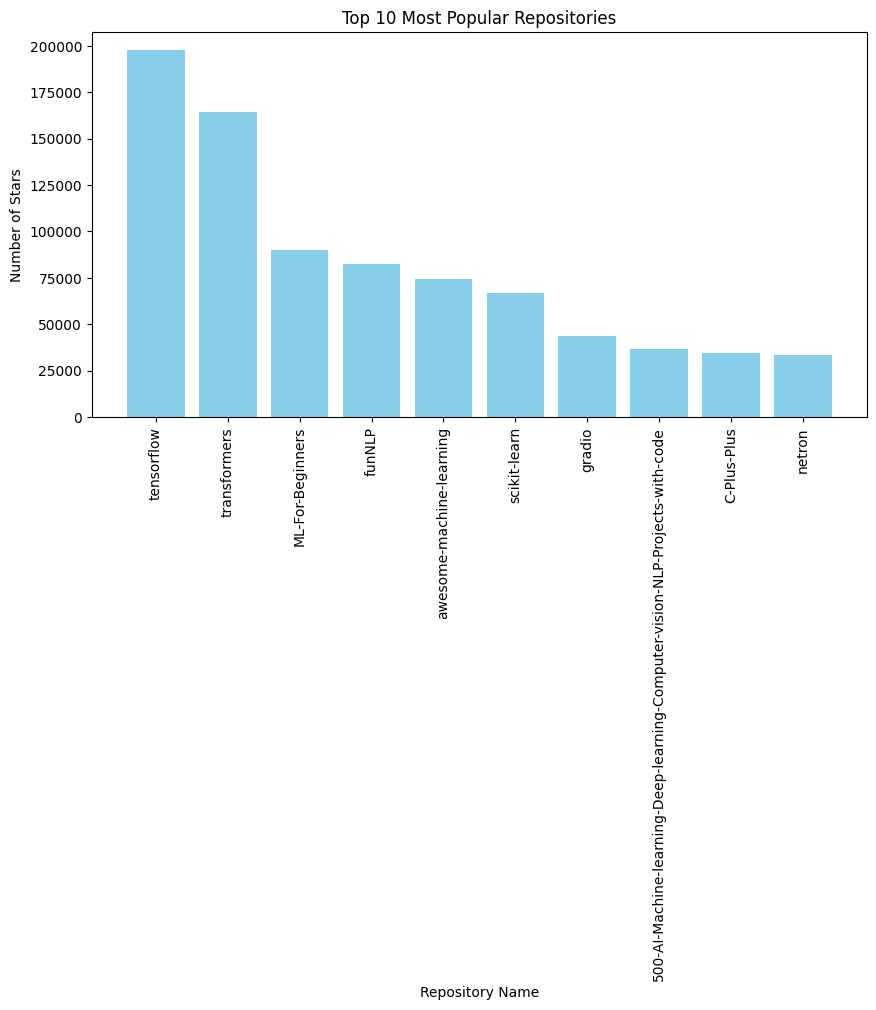

In [287]:
# 1. Bar Chart: Highlight the most popular repositories
plt.figure(figsize=(10, 5))
plt.bar(df_top10['name'], df_top10['stars'], color='skyblue')
plt.title('Top 10 Most Popular Repositories')
plt.xlabel('Repository Name')
plt.ylabel('Number of Stars')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

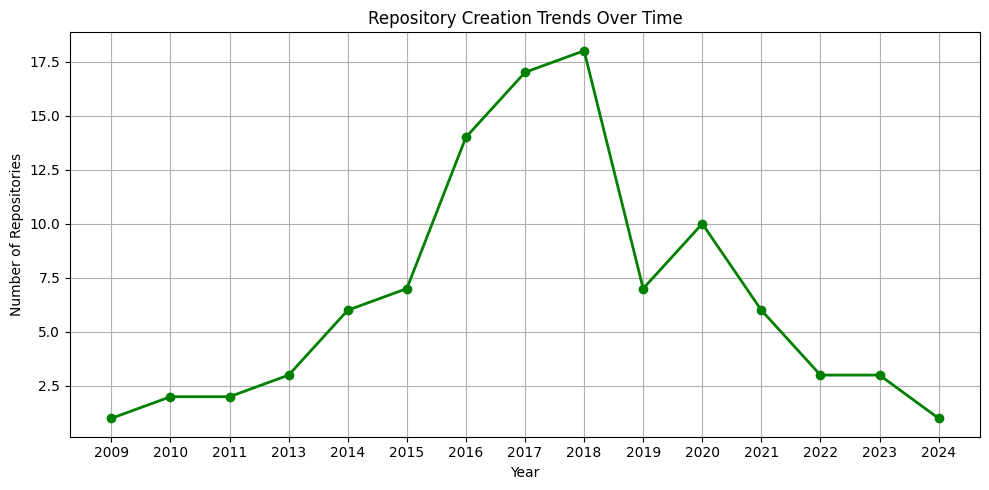

In [288]:
# 2. Line Chart: Creation Trends Over Time
query_trend = """
SELECT strftime('%Y', created_date) AS year, COUNT(*) AS repo_count
FROM Repositories
GROUP BY year
ORDER BY year
"""
df_trend = pd.read_sql_query(query_trend, conn)

plt.figure(figsize=(10, 5))
plt.plot(df_trend['year'], df_trend['repo_count'], marker='o', color='green', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Number of Repositories')
plt.title('Repository Creation Trends Over Time')
plt.grid(True)
plt.tight_layout()
plt.show()

In [289]:
# Step 8: Interpret Results
insights = """
=== Final Analysis Insights & Key Findings ===

1. Top Repositories:
   - 'tensorflow' leads the chart as the most starred repository (~200k stars),
     followed closely by 'transformers'.
   - Machine Learning and AI frameworks dominate the top ranks.

2. Distribution of Stars:
   - The majority of repositories have under 25,000 stars.
   - High-star repositories (>100k) are rare outliers representing top-tier projects.

3. Language Distribution & Trends:
   - Python is the primary language driving the most popular open-source projects.
   - Creation trends show steady growth in repository setups over recent years.
"""

print(insights)


=== Final Analysis Insights & Key Findings ===

1. Top Repositories:
   - 'tensorflow' leads the chart as the most starred repository (~200k stars), 
     followed closely by 'transformers'.
   - Machine Learning and AI frameworks dominate the top ranks.

2. Distribution of Stars:
   - The majority of repositories have under 25,000 stars.
   - High-star repositories (>100k) are rare outliers representing top-tier projects.

3. Language Distribution & Trends:
   - Python is the primary language driving the most popular open-source projects.
   - Creation trends show steady growth in repository setups over recent years.



## Ethics Reflection Answers

### Question 1: Why is it important to verify data collected from public APIs?
**Answer:** Public APIs can contain missing, outdated, or duplicated records due to API rate limits or incomplete endpoints. Verifying the data ensures its integrity, accuracy, and reliability before running analysis.

### Question 2: Why should data analysts document the source of their data?
**Answer:** Documenting data sources builds trust, transparency, and credibility. It allows other analysts to trace back data lineage, audit the process, and reproduce the results accurately.

### Question 3: How can missing or inaccurate data affect data analysis and decision-making?
**Answer:** Inaccurate or incomplete data skews statistical findings and leads to false patterns. Decisions based on faulty data can result in misallocated resources, poor business strategy, and loss of confidence in analysis.